In [1]:
import logging
import os
import random

os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"

import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import callbacks, layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor, normalize_features
from xasml.models.io import read_from_h5
from xasml.models.metrics import calculate_accuracies, display_metrics

In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger("xasml")
logger.setLevel(logging.INFO)

plt.style.use("stylelib/presentation.mplstyle")

In [3]:
# Define some constants.
ELEMENT = "Fe"
JOB = "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN = -10 + ENERGY_SHIFT
ENERGY_MAX = 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"  # Z-score fails when adding noise.
OUTLIER_THRESHOLD = 4
PREFIX = os.path.join("figures", "cnn_classifier")
EXTENSION = "pdf"
DPI = 300

# Read data from file.
X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)

# Create a processor object.
processor = Processor(X, y, metas=metas)

In [4]:
def train_model(
    model,
    data,
    epochs=512,
    patience=64,
    learning_rate=1e-3,
    batch_size=32,
    class_weight=None,
):
    """Train a model using the given data and hyperparameters."""
    # Compile the model.
    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    # Define the callbacks.
    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )

    save_best = callbacks.ModelCheckpoint(
        f"{model.name}.keras",
        monitor="val_loss",
        verbose=0,
        save_best_only=True,
        mode="min",
        save_freq="epoch",
        initial_value_threshold=None,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=patience // 2, min_lr=1e-6, verbose=1
    )

    # Train the model.
    history = model.fit(
        data.X_train,
        data.y_train,
        validation_data=(data.X_val, data.y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, save_best, reduce_lr],
        verbose=1,
        class_weight=class_weight,
    )
    return history


def evaluate_model(model, data, history: keras.callbacks.History | None = None):
    """Evaluate the model using the given data and history."""
    # Recompile if the optimizer is missing (workaround for Keras 3 + Torch + restore_best_weights).
    if not hasattr(model, "optimizer"):
        model.compile(
            loss="binary_crossentropy",
            optimizer="adam",
            metrics=["accuracy"],
        )

    # Evaluate the model on the test set.
    _, test_acc = model.evaluate(data.X_test, data.y_test)

    # Print the test accuracy.
    print(f"Test accuracy: {test_acc:.3f}")

    if history is not None:
        # Plot the training and validation loss
        fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
        ax1, ax2 = ax

        ax1.plot(history.history["accuracy"], label="Training accuracy")
        ax1.plot(history.history["val_accuracy"], label="Validation accuracy")
        ax1.legend()
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Accuracy")

        ax2.plot(history.history["loss"], label="Training loss")
        ax2.plot(history.history["val_loss"], label="Validation loss")
        ax2.legend()
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")

        fig.tight_layout()
        fig.savefig(f"{PREFIX}_history.{EXTENSION}", dpi=DPI)

    return test_acc

2026-08-17 22:46:19,436 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:46:19,436 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:46:22,063 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:46:22,068 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:46:22,098 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


2026-08-17 22:46:22,115 - xasml.models.data - INFO - Removed 129 outlier(s) out of 2863 spectra (threshold=4, min_std=0.01).


2026-08-17 22:46:22,126 - xasml.models.data - INFO - Normalized the 'all' subset using the 'area' method.


2026-08-17 22:46:22,133 - xasml.models.data - INFO - Split data into training, testing, and validation sets.


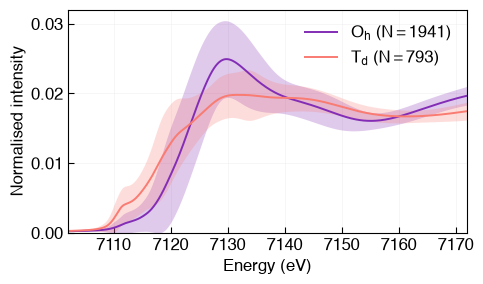

In [5]:
label_encoder = LabelEncoder()
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

# Convert the labels to integers as required by the sigmoid activation function.
label_encoder.fit(processor.y)
processor.y = np.array(label_encoder.transform(processor.y))

energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.normalize(method=NORMALIZATION, reference=energies)
# Explicitly shuffle the data to ensure random splits, preventing ordered data bias.
processor.split(
    test_size=0.15, val_size=0.15, random_seed=RANDOM_SEED, shuffle=True, stratify=True
)

mask_o6 = processor.y == label_encoder.transform(["O:6"])[0]
mask_t4 = processor.y == label_encoder.transform(["T:4"])[0]

# Colours drawn from the Petroff10 colour-blind-safe palette
# (Petroff, arXiv:2107.02270; included in matplotlib >= 3.10).
OH_COLOR = "#832db6"
TD_COLOR = "#f97b72"

fig, ax = plt.subplots(figsize=(5, 3))

for mask, color, label in [
    (mask_o6, OH_COLOR, rf"$O_h$ ($N={mask_o6.sum()}$)"),
    (mask_t4, TD_COLOR, rf"$T_d$ ($N={mask_t4.sum()}$)"),
]:
    spectra = processor.X[mask, :]
    mean = spectra.mean(axis=0)
    std = spectra.std(axis=0)
    ax.plot(energies, mean, lw=1.4, color=color, label=label)
    ax.fill_between(energies, mean - std, mean + std, color=color, alpha=0.25, lw=0)

ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalised intensity")
ax.legend(loc="upper right", frameon=False)

fig.tight_layout()
fig.savefig(f"{PREFIX}_spectra.{EXTENSION}", dpi=DPI, bbox_inches="tight")

## Classifier

In [6]:
# Re-seed immediately before building the model so the weight initialisation is
# reproducible across runs.
keras.utils.set_random_seed(RANDOM_SEED)

CONV_KW = {"activation": "relu", "padding": "same", "kernel_initializer": "he_normal"}
DENSE_KW = {"activation": "relu", "kernel_initializer": "he_normal"}

model = models.Sequential(name="cnn_classifier")
model.add(layers.Input(shape=(len(energies),)))
model.add(layers.Reshape((len(energies), 1)))

# Block 1: 8 filters
model.add(layers.Conv1D(8, 3, **CONV_KW))
model.add(layers.Conv1D(8, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 2: 16 filters
model.add(layers.Conv1D(16, 3, **CONV_KW))
model.add(layers.Conv1D(16, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 3: 32 filters
model.add(layers.Conv1D(32, 3, **CONV_KW))
model.add(layers.Conv1D(32, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 4: 64 filters
model.add(layers.Conv1D(64, 3, **CONV_KW))
model.add(layers.Conv1D(64, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Dense head
model.add(layers.Flatten())
model.add(layers.Dense(64, **DENSE_KW))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(32, **DENSE_KW))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 701, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 701, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 701, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 350, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 350, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 350, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 175, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 175, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 87, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 87, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 87, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       176,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,953 (792.79 KB)

 Trainable params: 202,953 (792.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_path = f"{model.name}.keras"

classes = np.unique(processor.y_train)
weights = class_weight.compute_class_weight(
    "balanced", classes=classes, y=processor.y_train
)
class_weights = dict(zip(classes, weights))
print(f"Class weights: {class_weights}")
print(f"Training set shape: {processor.X_train.shape}")
print(f"Validation set shape: {processor.X_val.shape}")

if os.path.exists(model_path):
    # Reuse the saved best model so re-runs reproduce the reported metrics.
    model = keras.models.load_model(model_path, compile=False)
    model.summary()
    history = None
else:
    history = train_model(
        model,
        processor,
        epochs=512,
        patience=32,
        learning_rate=1e-4,
        batch_size=32,
        class_weight=class_weights,
    )


Class weights: {np.int64(0): np.float64(0.7043446244477173), np.int64(1): np.float64(1.7234234234234234)}
Training set shape: (1913, 701)
Validation set shape: (410, 701)
Epoch 1/512


 1/60 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - accuracy: 0.5938 - loss: 0.7284

 4/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6641 - loss: 0.6845  

 7/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6964 - loss: 0.6706

10/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6906 - loss: 0.6778

...

53/60 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9452 - loss: 0.1537

56/60 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9442 - loss: 0.1530

59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9439 - loss: 0.1540


Epoch 145: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9435 - loss: 0.1554 - val_accuracy: 0.9195 - val_loss: 0.2640 - learning_rate: 2.5000e-05


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.3173

 9/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9340 - loss: 0.1775 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9367 - loss: 0.1688

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9367 - loss: 0.1688


Test accuracy: 0.937


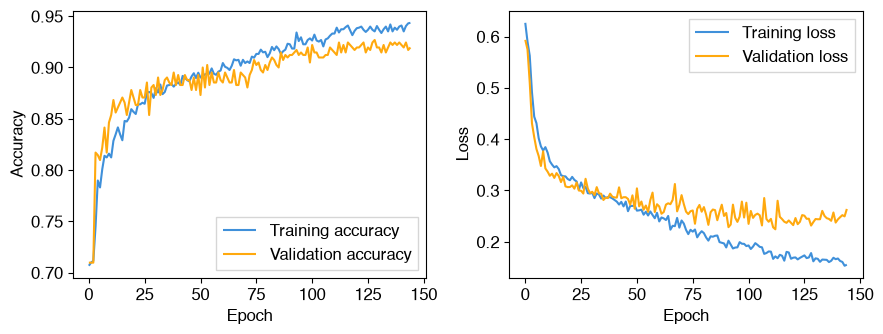

In [8]:
accuracy = evaluate_model(model, processor, history)

In [9]:
model_path = f"{model.name}.keras"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")

model = keras.models.load_model(model_path, compile=False)
model.summary()

Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 701, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 701, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 701, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 350, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 350, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 350, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 175, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 175, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 87, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 87, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 87, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       176,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,953 (792.79 KB)

 Trainable params: 202,953 (792.79 KB)

 Non-trainable params: 0 (0.00 B)

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


2026-08-17 22:49:51,192 - xasml.models.metrics - INFO - Balanced accuracy: 92.3%


2026-08-17 22:49:51,192 - xasml.models.metrics - INFO -   0: 95.5%


2026-08-17 22:49:51,193 - xasml.models.metrics - INFO -   1: 89.1%


2026-08-17 22:49:51,194 - xasml.models.metrics - INFO - Accuracy: 93.7%


2026-08-17 22:49:51,194 - xasml.models.metrics - INFO - F1 score: 93.7%


{'accuracy': 0.9367396593673966,
 'balanced': 0.9231178772879015,
 np.int64(0): 0.9554794520547946,
 np.int64(1): 0.8907563025210085}

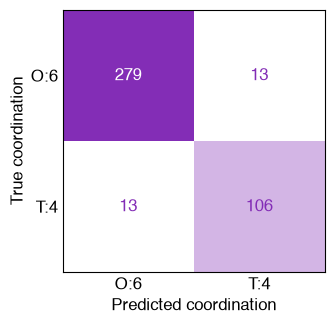

In [10]:
# Recast the predictions as booleans to be able to calculate the confusion matrix.
THRESHOLD = 0.5
y_pred = model.predict(processor.X_test)
y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])

display_metrics(
    processor.y_test,
    y_pred,
    display_labels=LABELS,
    cm_name=f"{model.name}.{EXTENSION}",
    dpi=DPI,
)

## Shift

2026-08-17 22:49:51,308 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:49:51,308 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:49:54,614 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:49:54,623 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:49:54,632 - xasml.models.data - INFO - Shifting the features to the left by 10 indices.


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


2026-08-17 22:50:25,126 - xasml.models.metrics - INFO - Balanced accuracy: 90.1%


2026-08-17 22:50:25,126 - xasml.models.metrics - INFO -   O:6: 94.5%


2026-08-17 22:50:25,126 - xasml.models.metrics - INFO -   T:4: 85.7%


  Shift (eV)       O:6       T:4    Balanced
--------------------------------------------
        -1.0    93.2%    89.9%      91.5%
        -0.5    94.5%    88.2%      91.4%
         0.0    95.5%    89.1%      92.3%
         0.5    95.5%    89.1%      92.3%
         1.0    94.5%    85.7%      90.1%


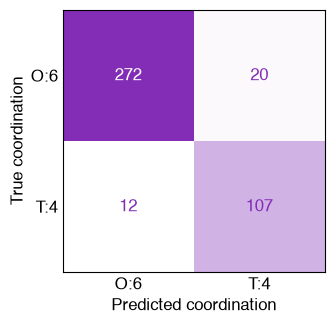

In [11]:
SHIFTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
shift_results = []

for shift in SHIFTS:
    # Reset all data and split it again as the shift will affect it.
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    processor.y = np.array(label_encoder.fit_transform(processor.y))
    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    processor.shift(shift, reference=energies)
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.normalize(method=NORMALIZATION, reference=energies)
    processor.split(
        test_size=0.15,
        val_size=0.15,
        random_seed=RANDOM_SEED,
        shuffle=True,
        stratify=True,
    )

    y_pred = model.predict(processor.X_test)
    y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])

    y_test_decoded = label_encoder.inverse_transform(processor.y_test)
    y_pred_decoded = label_encoder.inverse_transform(y_pred)
    if shift == -1.0:
        display_metrics(
            y_test_decoded,
            y_pred_decoded,
            display_labels=LABELS,
            cm_name=f"{PREFIX}_shift_{shift:+.1f}eV_cm.{EXTENSION}",
            dpi=DPI,
        )
    accuracies = calculate_accuracies(y_test_decoded, y_pred_decoded)
    shift_results.append((shift, accuracies))

# Summary table.
header = (
    f"{'Shift (eV)':>12}"
    + "".join(f"{cls:>10}" for cls in LABELS)
    + f"{'Balanced':>12}"
)
print(header)
print("-" * len(header))
for shift, accs in shift_results:
    row = (
        f"{shift:>12}"
        + "".join(f"{accs[cls]:>9.1%}" for cls in LABELS)
        + f"{accs['balanced']:>11.1%}"
    )
    print(row)

## Noise

2026-08-17 22:50:25,173 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:50:25,173 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:50:28,307 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:50:28,312 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:50:28,326 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


2026-08-17 22:50:57,907 - xasml.models.metrics - INFO - Balanced accuracy: 92.7%


2026-08-17 22:50:57,908 - xasml.models.metrics - INFO -   O:6: 95.5%


2026-08-17 22:50:57,908 - xasml.models.metrics - INFO -   T:4: 89.9%


         SNR       O:6       T:4    Balanced
--------------------------------------------
          10    96.6%    85.7%      91.1%
          25    96.2%    89.1%      92.7%
          50    95.5%    89.9%      92.7%
         100    95.2%    89.1%      92.1%
         250    95.5%    89.9%      92.7%


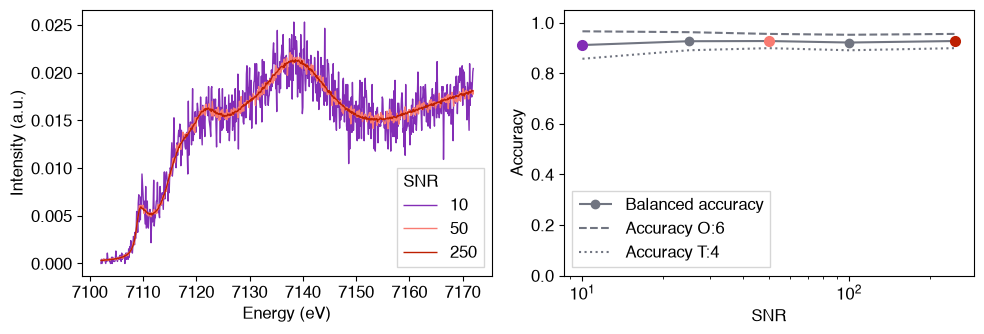

In [12]:
ID_TO_PLOT = 13
SNRS = [10, 25, 50, 100, 250]
SELECTED_SNRS = [10, 50, 250]
# Reuse the violet and rose from the class plot; add Petroff10 red as the third.
SNR_COLORS = ["#832db6", "#f97b72", "#bd1f01"]
ACCURACY_COLOR = "#717581"

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax1, ax2 = ax

noise_results = []
accuracies = []
color_index = 0
for snr in SNRS:
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    processor.y = np.array(label_encoder.fit_transform(processor.y))
    energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.split(
        test_size=0.15,
        val_size=0.15,
        random_seed=RANDOM_SEED,
        shuffle=True,
        stratify=True,
    )
    processor.add_poisson_noise(
        snr=snr,
        reference_intensity=FE_REFERENCE_MBARN,
        normalization=NORMALIZATION,
        reference=energies,
        subset="test",
        random_seed=RANDOM_SEED,
    )

    if snr in SELECTED_SNRS:
        data = processor.X_test.transpose()[:, ID_TO_PLOT]
        ax1.plot(energies, data, lw=1, color=SNR_COLORS[color_index], label=f"{snr}")
        color_index += 1

    y_pred = model.predict(processor.X_test)
    y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])
    y_test_decoded = label_encoder.inverse_transform(processor.y_test)
    y_pred_decoded = label_encoder.inverse_transform(y_pred)
    accs = calculate_accuracies(y_test_decoded, y_pred_decoded)
    accuracies.append(accs["balanced"])
    noise_results.append((snr, accs))

ax1.legend(title="SNR", alignment="left")
ax1.set_xlabel("Energy (eV)")
ax1.set_ylabel("Intensity (a.u.)")

# Plot balanced accuracy as solid line with colored markers for selected SNRs.
ax2.plot(
    SNRS,
    accuracies,
    marker="o",
    ls="-",
    color=ACCURACY_COLOR,
    label="Balanced accuracy",
)

for i, snr in enumerate(SELECTED_SNRS):
    ax2.plot(snr, accuracies[SNRS.index(snr)], marker="o", ms=7, color=SNR_COLORS[i])

# Plot per-class accuracies with distinct line styles.
o6_accs = [accs["O:6"] for _, accs in noise_results]
t4_accs = [accs["T:4"] for _, accs in noise_results]
ax2.plot(SNRS, o6_accs, ls="--", color=ACCURACY_COLOR, label="Accuracy O:6")
ax2.plot(SNRS, t4_accs, ls=":", color=ACCURACY_COLOR, label="Accuracy T:4")

ax2.set_xscale("log")
ax2.set_xlabel("SNR")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend()
fig.tight_layout()
fig.savefig(f"{PREFIX}_poisson_noise.{EXTENSION}", dpi=DPI)

# Summary table.
header = f"{'SNR':>12}" + "".join(f"{cls:>10}" for cls in LABELS) + f"{'Balanced':>12}"
print(header)
print("-" * len(header))
for snr, accs in noise_results:
    row = (
        f"{snr:>12}"
        + "".join(f"{accs[cls]:>9.1%}" for cls in LABELS)
        + f"{accs['balanced']:>11.1%}"
    )
    print(row)

### Denoising sanity check


2026-08-17 22:50:58,154 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:50:58,154 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:51:01,210 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:51:01,215 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:51:01,230 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


2026-08-17 22:51:01,247 - xasml.models.data - INFO - Removed 129 outlier(s) out of 2863 spectra (threshold=4, min_std=0.01).


2026-08-17 22:51:01,344 - xasml.models.data - INFO - Added Poisson noise to the 'all' subset using an SNR of 10 at a reference intensity of 0.037.


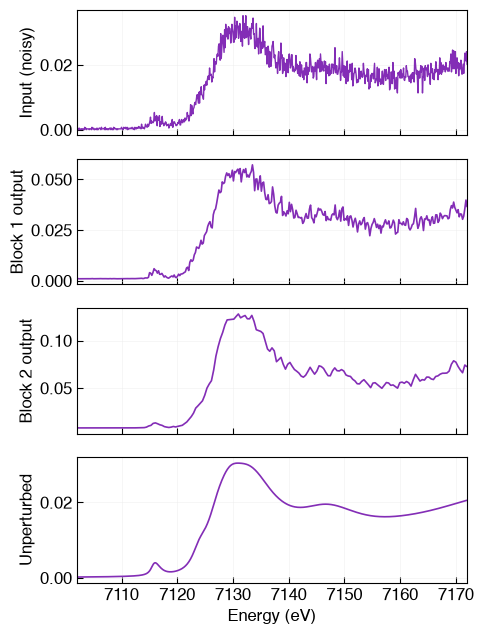

In [13]:
# Visualise how the first two conv blocks suppress Poisson noise on a single spectrum.
MATERIAL_TO_PLOT = "mp-19770"

processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)
processor.y = np.array(label_encoder.fit_transform(processor.y))
energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)

# Select by material id so the figure does not depend on the order of the split.
idx = next(
    i
    for i, meta in enumerate(processor.metas)
    if meta["material_id"] == MATERIAL_TO_PLOT
)

spectrum_clean = normalize_features(
    processor.X[idx : idx + 1], NORMALIZATION, energies
)[0]
processor.add_poisson_noise(
    snr=10,
    reference_intensity=FE_REFERENCE_MBARN,
    normalization=NORMALIZATION,
    reference=energies,
    random_seed=RANDOM_SEED,
)
spectrum_noisy = processor.X[idx].copy()

# Both traces are taken at the output of a block, that is after its pooling step,
# so the two panels show the same kind of quantity on progressively coarser grids.
first_block = keras.Model(inputs=model.inputs, outputs=model.layers[3].output)
activation1 = first_block.predict(spectrum_noisy.reshape(1, -1), verbose=0)[0]
activation1_mean = activation1.mean(axis=-1)
energies_block1 = np.linspace(energies[0], energies[-1], activation1_mean.size)

second_block = keras.Model(inputs=model.inputs, outputs=model.layers[6].output)
activation2 = second_block.predict(spectrum_noisy.reshape(1, -1), verbose=0)[0]
activation2_mean = activation2.mean(axis=-1)
energies_block2 = np.linspace(energies[0], energies[-1], activation2_mean.size)

COLOR = "#832db6"

fig, axes = plt.subplots(4, 1, figsize=(5, 6.5), sharex=True)

axes[0].plot(energies, spectrum_noisy, lw=1.0, color=COLOR)
axes[0].set_ylabel("Input (noisy)")

axes[1].plot(energies_block1, activation1_mean, lw=1.2, color=COLOR)
axes[1].set_ylabel("Block 1 output")

axes[2].plot(energies_block2, activation2_mean, lw=1.2, color=COLOR)
axes[2].set_ylabel("Block 2 output")

axes[3].plot(energies, spectrum_clean, lw=1.2, color=COLOR)
axes[3].set_ylabel("Unperturbed")
axes[3].set_xlabel("Energy (eV)")

for ax in axes:
    ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(direction="in", length=4, top=False, right=False)
    ax.set_xlim(energies[0], energies[-1])

fig.tight_layout()
fig.savefig(f"{PREFIX}_noise_denoising.{EXTENSION}", dpi=DPI, bbox_inches="tight")

## Self-absorption

2026-08-17 22:51:01,635 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:51:01,635 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:51:04,945 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:51:04,950 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:51:04,964 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


...

2026-08-17 22:51:09,160 - xasml.models.metrics - INFO -   O:6: 79.5%


2026-08-17 22:51:09,160 - xasml.models.metrics - INFO -   T:4: 92.4%


2026-08-17 22:51:09,162 - xasml.models.metrics - INFO - Accuracy: 83.2%


2026-08-17 22:51:09,162 - xasml.models.metrics - INFO - F1 score: 83.9%


{'accuracy': 0.8321167883211679,
 'balanced': 0.8594451479221825,
 np.str_('O:6'): 0.7945205479452054,
 np.str_('T:4'): 0.9243697478991597}

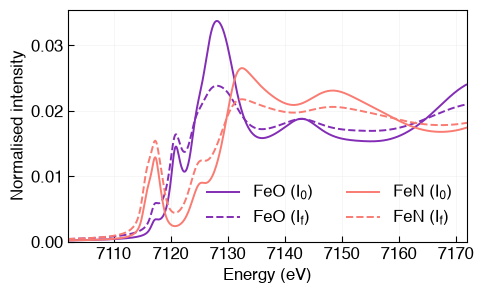

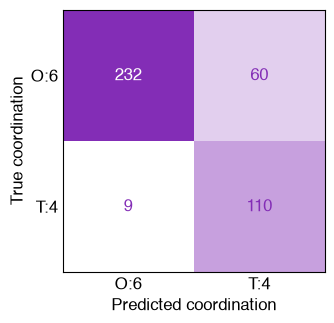

In [14]:
from xasml.models.fluorescence import calculate_spectrum

# Match the Petroff10 colours used for the class-mean spectra in Figure 1.
OH_COLOR = "#832db6"
TD_COLOR = "#f97b72"
COORD_COLORS = {"O:6": OH_COLOR, "T:4": TD_COLOR}

fig, ax = plt.subplots(figsize=(5, 3.09))

processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

processor.y = np.array(label_encoder.fit_transform(processor.y))
energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(
    test_size=0.15, val_size=0.15, random_seed=RANDOM_SEED, shuffle=True, stratify=True
)

# Find one O:6 (FeO) and one T:4 (FeN) by formula in the full processed data.
TARGETS = [("FeO", "O:6"), ("FeN", "T:4")]

SA_KWARGS = {
    "binder": "boron nitride",
    "phi": 45,
    "theta": 45,
    "absorbing_element": ELEMENT,
    "compound_weight_fraction": 0.1,
    "thickness": 0.1,
}

y_decoded = label_encoder.inverse_transform(processor.y)
for formula, coordination in TARGETS:
    idx = next(
        i
        for i, (meta, label) in enumerate(zip(processor.metas, y_decoded))
        if meta["structure"].composition.reduced_formula == formula
        and label == coordination
    )
    spectrum_clean = processor.X[idx]
    spectrum_fluor = calculate_spectrum(
        energies=energies,
        intensity=spectrum_clean,
        compound=processor.metas[idx]["structure"],
        **SA_KWARGS,  # type: ignore
    )
    spectrum_clean = spectrum_clean / np.trapezoid(spectrum_clean, energies)
    # Normalize the fluorescence spectrum.
    spectrum_fluor = spectrum_fluor / np.trapezoid(spectrum_fluor, energies)
    color = COORD_COLORS[coordination]
    ax.plot(
        energies,
        spectrum_clean,
        lw=1.4,
        color=color,
        label=rf"{formula} ($I_0$)",
    )
    ax.plot(
        energies,
        spectrum_fluor,
        lw=1.4,
        ls="--",
        color=color,
        label=rf"{formula} ($I_f$)",
    )

ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalised intensity")
ax.legend(loc="lower right", ncol=2, frameon=False)

fig.tight_layout()
fig.savefig(f"{PREFIX}_with_incident_beam_self_absorption.{EXTENSION}", dpi=DPI)

# Apply self-absorption to all test spectra and predict on the distorted set.
X_test_sa = np.array([
    calculate_spectrum(
        energies=energies,
        intensity=spectrum,
        compound=meta["structure"],
        **SA_KWARGS,  # type: ignore
    )
    for spectrum, meta in zip(processor.X_test, processor.metas_test)
])
# Re-normalize each self-absorbed spectrum.
X_test_sa = X_test_sa / np.trapezoid(X_test_sa, energies, axis=1)[:, np.newaxis]

y_pred = model.predict(X_test_sa)
y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])

y_test_decoded = label_encoder.inverse_transform(processor.y_test)
y_pred_decoded = label_encoder.inverse_transform(y_pred)
display_metrics(
    y_test_decoded,
    y_pred_decoded,
    display_labels=LABELS,
    cm_name=f"{PREFIX}_with_incident_beam_self_absorption_cm.{EXTENSION}",
    dpi=DPI,
)
